In [ ]:
# install image with file id
!gdown '1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2'

Downloading...
From: https://drive.google.com/uc?id=1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2
To: /content/LAB03 PIC1.png
100% 729k/729k [00:00<00:00, 8.42MB/s]


# Section 1
Read and show the image

In [ ]:
# install image with file id
!gdown '1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2'

Downloading...
From: https://drive.google.com/uc?id=1_N8qe3XWwKbCeXKAkvH8gnR-Uvcvd5i2
To: /content/LAB03 PIC1.png
100% 729k/729k [00:00<00:00, 9.99MB/s]


## Answer

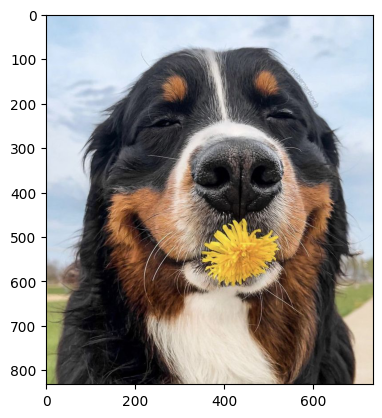

In [ ]:
# Answer your code here
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
image = Image.open('/content/LAB03 PIC1.png')
plt.imshow(image)
plt.show()


# Section 2
Use cv.resize() for scaling the image to 50% of the original size and show the results.

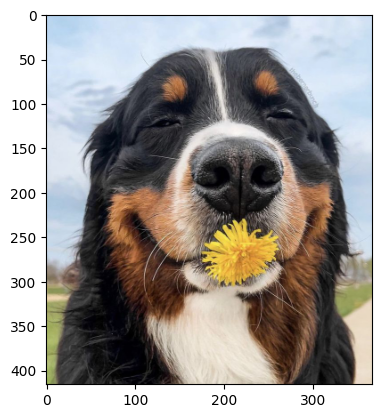

In [ ]:
import cv2
img = cv2.imread('/content/LAB03 PIC1.png')
width = int(img.shape[1] * 0.5)
height = int(img.shape[0] * 0.5)
dim = (width, height)
resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.show()

## Answer

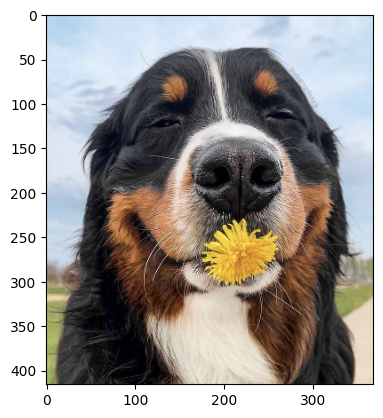

In [ ]:
# Answer your code here
img = cv2.imread('/content/LAB03 PIC1.png')
rel_res = cv2.resize(img,None,fx=0.5, fy=0.5, interpolation = cv2.INTER_CUBIC)
plt.imshow(cv2.cvtColor(rel_res, cv2.COLOR_BGR2RGB))
plt.show()

# Section 3
Apply theory of *object tracking* to extract blue colored of dog image and

write the code to:

  1. Convert from BGR to YCrCb color-space.  (Use image from section 1)
  2. Threshold the YCrCb image for a range of blue color.
  3. Extract only the blue position of image.

  



In [ ]:
blue = np.uint8([[[10,0,0 ],[50,0,0 ],[100,0,0 ],[200,0,0 ],[255,0,0 ]]])
hsv_blue = cv2.cvtColor(blue,cv2.COLOR_BGR2YCrCb)
print(hsv_blue)

[[[  1 127 133]
  [  6 124 153]
  [ 11 120 178]
  [ 23 112 228]
  [ 29 107 255]]]


In [ ]:
w = cv2.cvtColor(np.uint8([[[255,255,255],
                            [255,255,255],
                            [255,255,255]]]),cv2.COLOR_BGR2YCrCb)
print(w)

[[[255 128 128]
  [255 128 128]
  [255 128 128]]]


## Answer 3.1

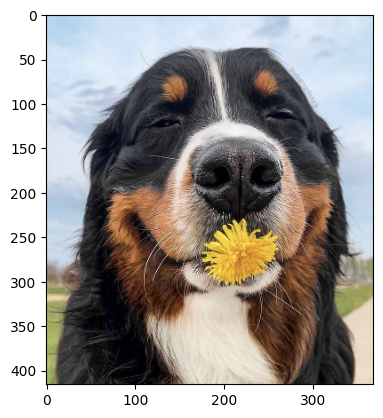

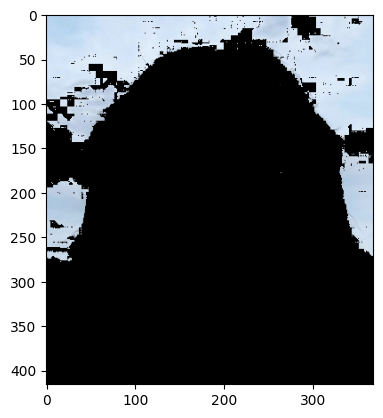

In [ ]:
# Answer your code here

from google.colab.patches import cv2_imshow
# img = cv2.imread('/content/LAB03 PIC1.png')
img_ycrcb = cv2.cvtColor(rel_res, cv2.COLOR_BGR2YCrCb)

lower_blue = np.array([10, 100, 128], dtype=np.uint8)
upper_blue = np.array([255, 120, 210], dtype=np.uint8)#190

mask = cv2.inRange(img_ycrcb, lower_blue, upper_blue)
result = cv2.bitwise_and(rel_res, rel_res, mask=mask)

# plot
plt.imshow(cv2.cvtColor(rel_res, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()


Another object tracking in dog image try to extract only yellow colored of flower.

write the code to:

1. Convert from BGR to HSV color-space. (Use image from section 1)
2. Threshold the HSV image for a range of yellow color.
3. Extract only the yellow position of image.

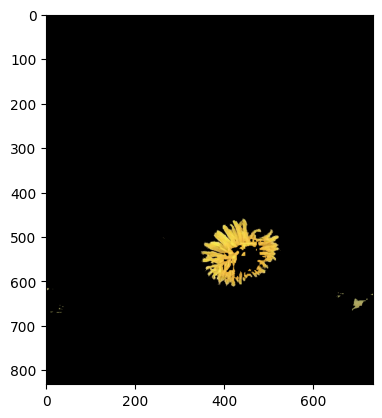

In [ ]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([30, 255, 255])

mask = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

result = cv2.bitwise_and(img, img, mask=mask)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

## Answer 3.2

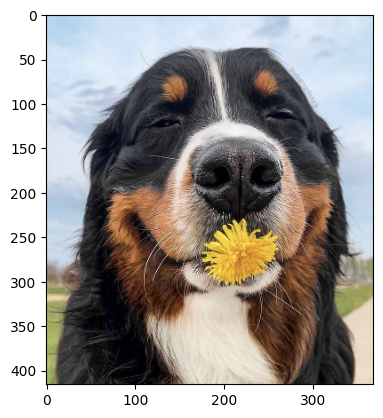

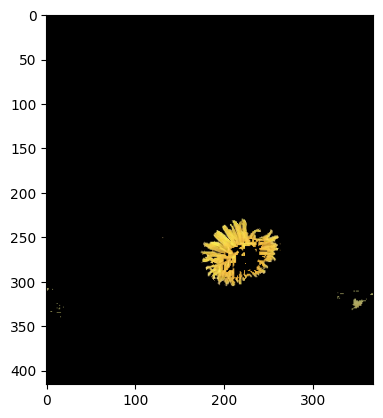

In [ ]:
# Answer your code here
img_hsv = cv2.cvtColor(rel_res, cv2.COLOR_BGR2HSV)

lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([30, 255, 255])

mask = cv2.inRange(img_hsv, lower_yellow, upper_yellow)

result = cv2.bitwise_and(rel_res, rel_res, mask=mask)

# plot
plt.imshow(cv2.cvtColor(rel_res, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

# Section 4
Use the cv.getRotationMatrix2D() and cv.warpAffine() functions and write the code to:

  1. Rotate an image around its center at 45 degrees without scaling.
  2. Rotate the same image around its center at 45 degrees with two different scaling factors like: 0.75, 1.5, etc.
  3. Display the results and explain the impact of the scaling factor on the output.

  



## Answer 4.1

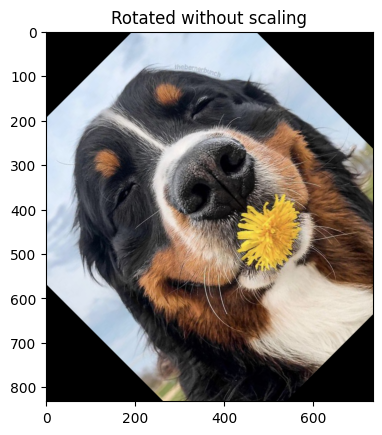

In [ ]:
# Use same image "LAB03 PIC1.png"
# Answer your code here
img = cv2.imread('/content/LAB03 PIC1.png')

height, width = img.shape[:2]
center = (width / 2, height / 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height))

plt.imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
plt.title("Rotated without scaling")
plt.show()

## Answer 4.2

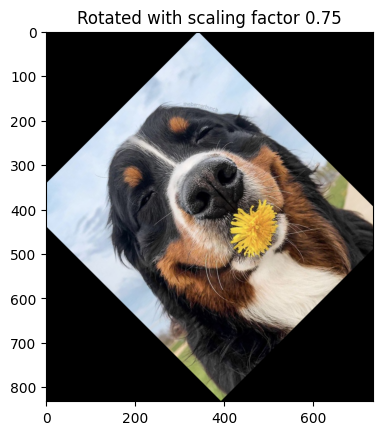

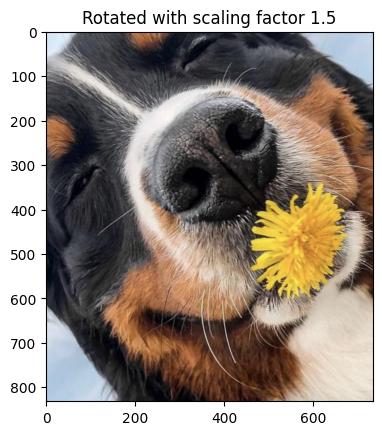

In [ ]:
# Answer your code here
scale_factors = [0.75, 1.5]
for scale in scale_factors:
    rotation_matrix = cv2.getRotationMatrix2D(center, 45, scale)
    rotated_img = cv2.warpAffine(img, rotation_matrix, (width, height))
    plt.imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Rotated with scaling factor {scale}")
    plt.show()

## Answer 4.3



```
To capture all of image,The scale must be fit in canvas,if not used to relate with rotation is cause to loose some of image.
```



# Section 5
 Use cv.getAffineTransform() and cv.warpAffine() functions to apply an affine transformation to an image， use the following points and the input image as the code '1U_l68HuSK9B8DvpOqEf6R2Gs-Ok0rsS6' and then display the results.
- Input points: [[50, 50], [200, 50], [50, 200]]
- Output points:
  1. Output points:[[10, 100], [200, 50], [100, 250]]
  2. Output points:[[50, 200], [200, 50], [100, 250]]

In [ ]:
!gdown '1U_l68HuSK9B8DvpOqEf6R2Gs-Ok0rsS6'

Downloading...
From: https://drive.google.com/uc?id=1U_l68HuSK9B8DvpOqEf6R2Gs-Ok0rsS6
To: /content/checkerboard.png
100% 67.7k/67.7k [00:00<00:00, 4.50MB/s]


## Answer 5.1

Output points:[[10, 100], [200, 50], [100, 250]]



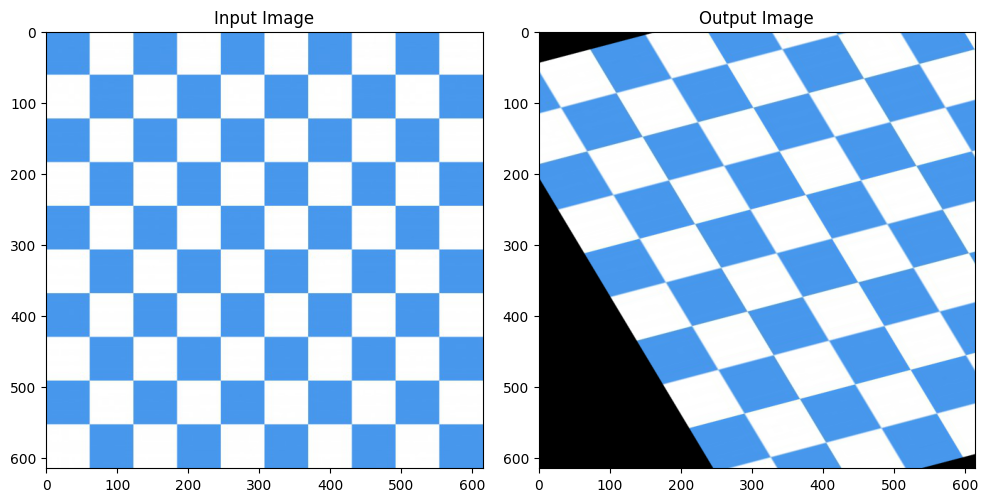

In [ ]:
# Answer your code here
def affine_transform(img:str, input_points:np.float32, output_points:np.float32):
  img = cv2.imread(img)
  rows, cols = img.shape[:2]

  M = cv2.getAffineTransform(input_points, output_points)

  Affine_transformed = cv2.warpAffine(img, M, (cols, rows))

  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.title('Input Image')

  plt.subplot(1, 2, 2)
  plt.imshow(cv2.cvtColor(Affine_transformed, cv2.COLOR_BGR2RGB))
  plt.title('Output Image')

  plt.tight_layout()
  plt.show()


Input_points =  np.float32([[50, 50], [200, 50], [50, 200]])
Output_points_1 = np.float32([[10, 100], [200, 50], [100, 250]])
Output_points_2 = np.float32([[50, 200], [200, 50], [100, 250]])

print('Output points:[[10, 100], [200, 50], [100, 250]]\n')
affine_transform('/content/checkerboard.png',
                 Input_points,Output_points_1,)

## Answer 5.2

Output points:[[50, 200], [200, 50], [100, 250]]



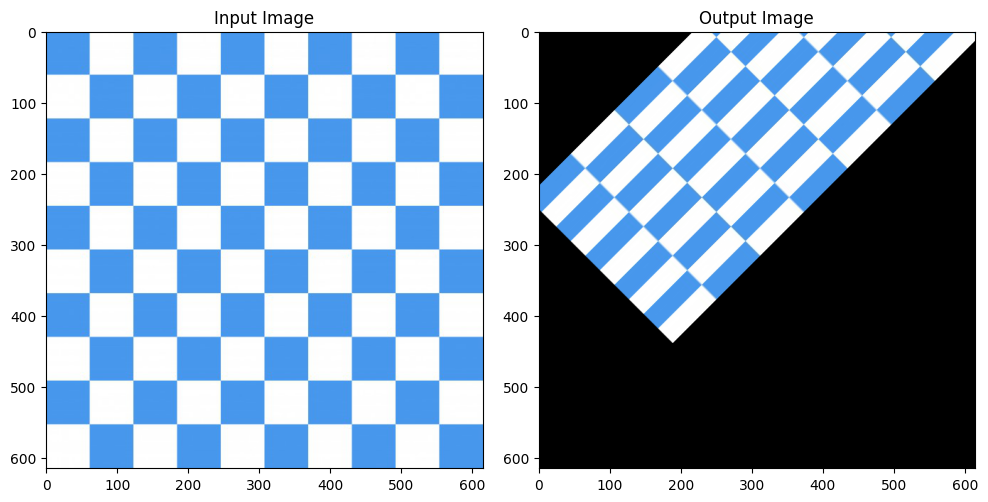

In [ ]:
# Answer your code here
print('Output points:[[50, 200], [200, 50], [100, 250]]\n')
affine_transform('/content/checkerboard.png',
                 Input_points,Output_points_2,)

# Section 6
Given the coordinates of a quadrilateral region in an image (pts1) and the corresponding points for a rectangular output (pts2) as follow：

- pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])

- pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
- output size as (300,300)

To do:
  1. Compute the transformation matrix using cv.getPerspectiveTransform().
  2. Apply the perspective transformation to the input image using cv.warpPerspective() with the specified output size (300, 300).

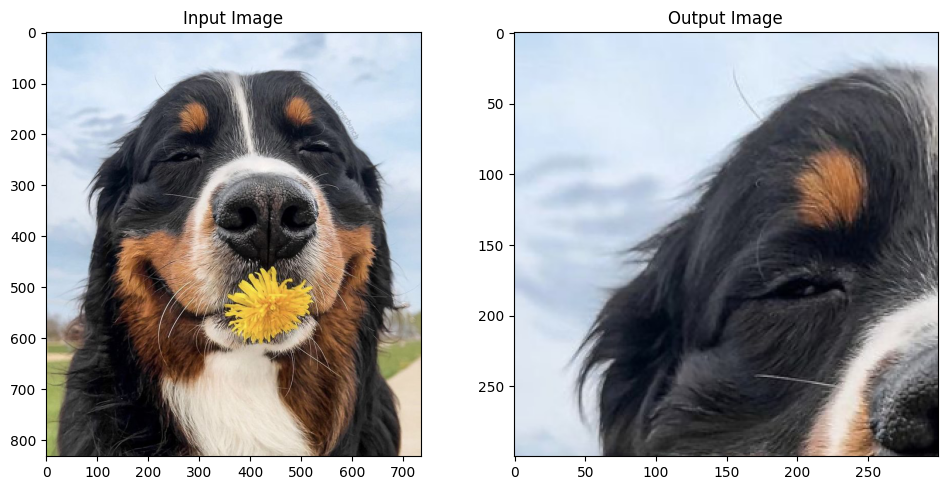

In [ ]:
# Use same image "LAB03 PIC1.png"
# Answer your code here
img= cv2.imread('LAB03 PIC1.png')
rows, cols = img.shape[:2]

# Define the input and outpoints
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

# 1. Compute the transformation matrix using cv.getPerspectiveTransform().
M = cv2.getPerspectiveTransform(pts1,pts2)

'''
  2. Apply the perspective transformation to the input image using
     cv.warpPerspective() with the specified output size (300, 300)'''

Perspective_transformed = cv2.warpPerspective(img,M,(300,300))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(Perspective_transformed, cv2.COLOR_BGR2RGB))
plt.title('Output Image')

plt.tight_layout()
plt.show()

#Section 7
You need to download new image from the link below (pancake.png). If I want you to create image that has only outline image (follow image below) for giving kids paint the part inside outline of pancake image. Which image thresholding solution will you use to get this type of pancake image ?

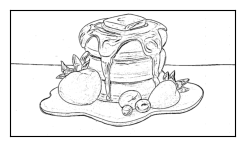

In [ ]:
!gdown '1F377cD-enYDoLSOibSKEZ1oqyqkJ61a8'

Downloading...
From: https://drive.google.com/uc?id=1F377cD-enYDoLSOibSKEZ1oqyqkJ61a8
To: /content/pancake.png
100% 311k/311k [00:00<00:00, 6.39MB/s]


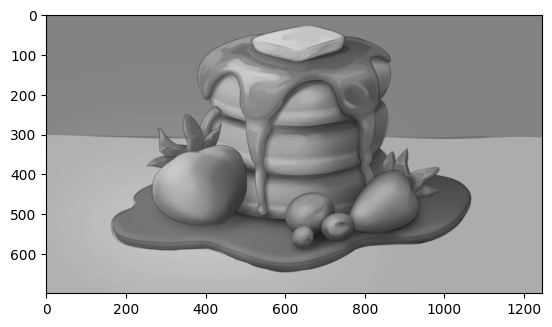

In [ ]:
# Answer your code here
img = cv2.imread('/content/pancake.png')
plt.imshow(img)
plt.show()

## Testing

### Global Thesholding

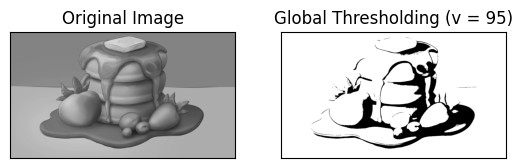

In [ ]:
titles = ['Original Image', 'Global Thresholding (v = 95)']
ret,th1 = cv2.threshold(img,95,255,cv2.THRESH_BINARY)

images = [img, th1]
for i in range(len(images)):
    plt.subplot(1,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

## Answer

In [ ]:
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_img = gray_img.astype('uint8')

### Adaptive Mean Thresholding

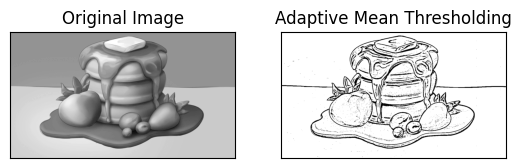

In [ ]:
titles = ['Original Image', 'Adaptive Mean Thresholding']

th2 = cv2.adaptiveThreshold(gray_img,255,cv2.ADAPTIVE_THRESH_MEAN_C,\
            cv2.THRESH_BINARY,11,2)

images = [gray_img, th2]
for i in range(len(images)):
    plt.subplot(1,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

### Adaptive Gaussian Thresholding

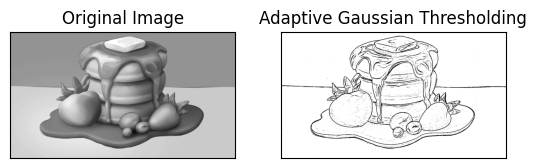

In [ ]:
titles = ['Original Image', 'Adaptive Gaussian Thresholding']

th3 = cv2.adaptiveThreshold(gray_img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,11,2)
images = [gray_img, th3]
for i in range(len(images)):
    plt.subplot(1,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()